<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Outliers**


This exercise, will work with a cleaned dataset to perform exploratory data analysis or EDA. 
Will explore the distribution of key variables and focus on identifying outliers in this lab.


## Objectives


In this exercise, will perform the following:


-  Analyze the distribution of key variables in the dataset.

-  Identify and remove outliers using statistical methods.

-  Perform relevant statistical and correlation analysis.


#### Install and import the required libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

<h3>Step 1: Load and Explore the Dataset</h3>


Load the dataset into a DataFrame and examine the structure of the data.


In [2]:
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

#Create the dataframe
df = pd.read_csv(file_url)

#Display the top 10 records
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 2: Plot the Distribution of Industry</h3>


Explore how respondents are distributed across different industries.

- Plot a bar chart to visualize the distribution of respondents by industry.

- Highlight any notable trends.


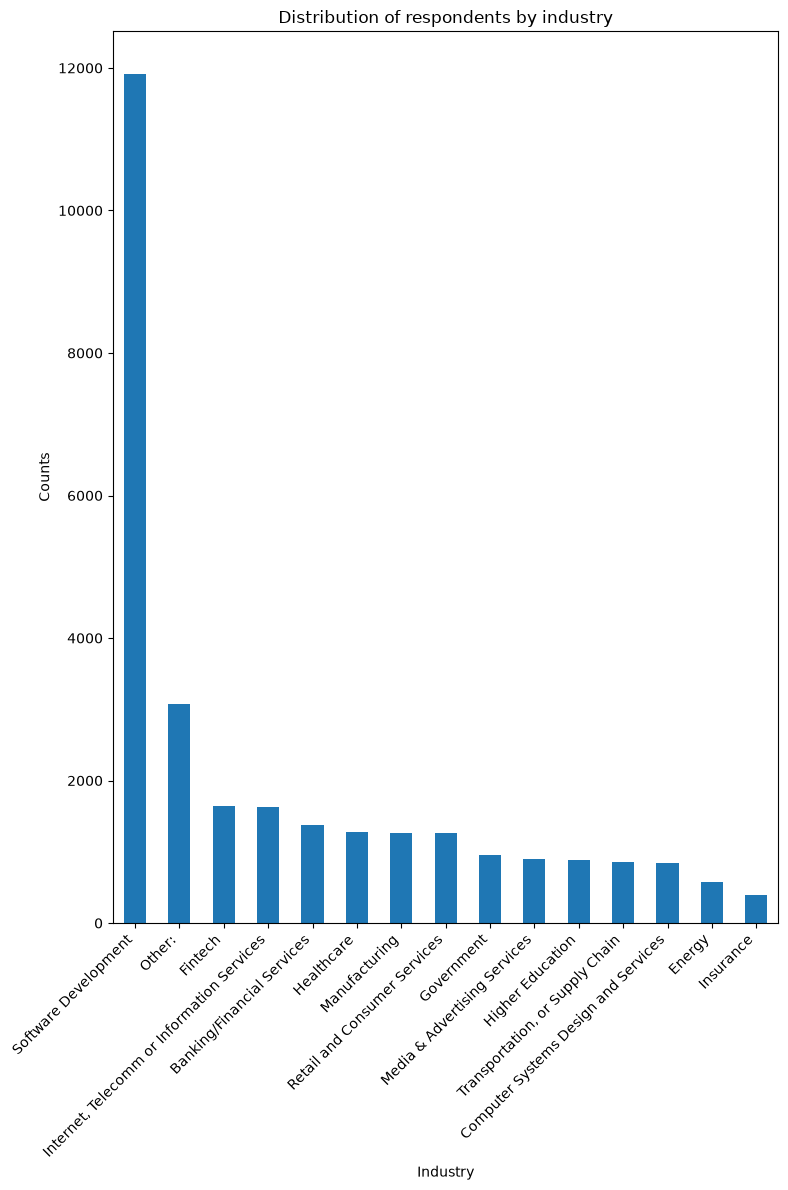

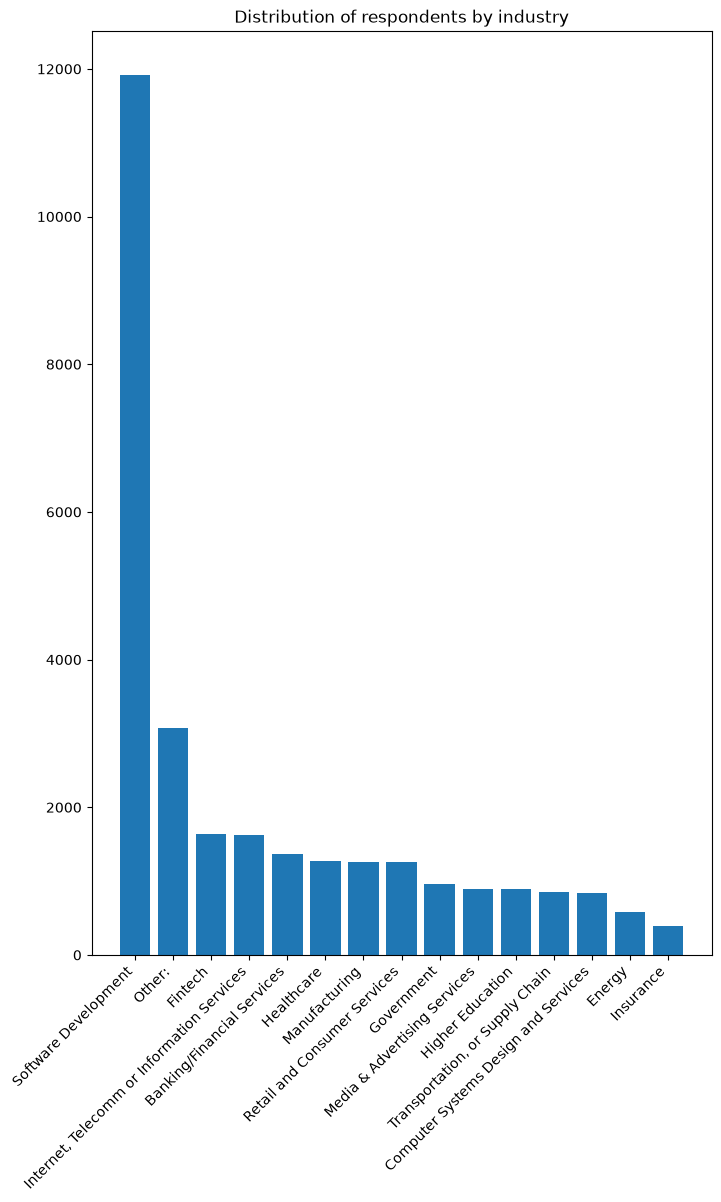

In [5]:
industry_count = df["Industry"].value_counts()
industry_count.plot(kind ="bar", figsize =(8,12))
plt.title("Distribution of respondents by industry")
plt.xlabel("Industry")
plt.ylabel("Counts")
plt.xticks(rotation = 45, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,12))
plt.bar(industry_count.index, industry_count.values)
plt.xticks(rotation = 45, ha = "right")
plt.title("Distribution of respondents by industry")
plt.show()


<h3>Step 3: Identify High Compensation Outliers</h3>


Identify respondents with extremely high yearly compensation.

- Calculate basic statistics (mean, median, and standard deviation) for `ConvertedCompYearly`.

- Identify compensation values exceeding a defined threshold (e.g., 3 standard deviations above the mean).


In [6]:
Yearly_mean = df["ConvertedCompYearly"].mean()
Yearly_median = df["ConvertedCompYearly"].median()
print("Median:", Yearly_median)
Yearly_mode= df["ConvertedCompYearly"].mode()[0]
print("Mode:",Yearly_mode) 
Yearly_std =  df["ConvertedCompYearly"].std()
print("Standard deviation:",Yearly_std)

Threshold = Yearly_mean + (3*Yearly_std)
print("Threshold:", Threshold)

High_salary = df[df["ConvertedCompYearly"] > Threshold][["ConvertedCompYearly", "Country", "Employment"]]
print("High Salary:",High_salary.head())
print("Number of high compensation values:", len(High_salary))

Median: 65000.0
Mode: 64444.0
Standard deviation: 186756.97308629757
Threshold: 646426.2065215341
High Salary:       ConvertedCompYearly                   Country           Employment
529              650000.0  United States of America  Employed, full-time
828             1000000.0  United States of America  Employed, full-time
1932             945000.0  United States of America  Employed, full-time
2171             750000.0  United States of America  Employed, full-time
2187            2000000.0                     Gabon  Employed, full-time
Number of high compensation values: 89

<h3>Step 4: Detect Outliers in Compensation</h3>


Identify outliers in the `ConvertedCompYearly` column using the IQR method.

- Calculate the Interquartile Range (IQR).

- Determine the upper and lower bounds for outliers.

- Count and visualize outliers using a box plot.


In [5]:
df['ConvertedCompYearly'].describe()

count    2.343500e+04
mean     8.615529e+04
std      1.867570e+05
min      1.000000e+00
25%      3.271200e+04
50%      6.500000e+04
75%      1.079715e+05
max      1.625660e+07
Name: ConvertedCompYearly, dtype: float64

Q1: 32712.0
Q3: 107971.5
IQR: 75259.5
Lower Bound: -80177.25
Upper Bound: 220860.75
OUTLIERS 428      230000.0
456      300000.0
461      254425.0
529      650000.0
545      400000.0
           ...   
40952    750000.0
41000    235000.0
41001    260000.0
41027    700000.0
41187    222834.0
Name: ConvertedCompYearly, Length: 978, dtype: float64
Number of outliers: 978
Outlier Percentage: 1.49%

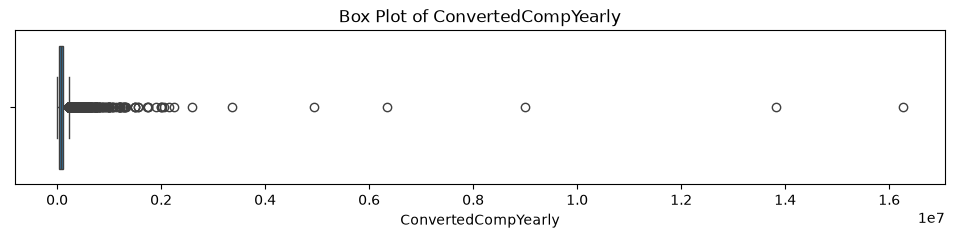

In [7]:
import pandas as pd
df_comp = df.dropna(subset=['ConvertedCompYearly'])
Q1 = df['ConvertedCompYearly'].quantile(0.25)
Q3 = df['ConvertedCompYearly'].quantile(0.75)
IQR = Q3 - Q1
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
outliers = df[
    (df['ConvertedCompYearly'] < lower_bound)|
    (df['ConvertedCompYearly'] > upper_bound)
]

print("OUTLIERS", outliers['ConvertedCompYearly'])

print("Number of outliers:", len(outliers))
outlier_percentage = (len(outliers) / len(df)) * 100
print(f"Outlier Percentage: {outlier_percentage:.2f}%")

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 2))
sns.boxplot(x=df['ConvertedCompYearly'])

plt.title('Box Plot of ConvertedCompYearly')
plt.xlabel('ConvertedCompYearly')
plt.show()

<h3>Step 5: Remove Outliers and Create a New DataFrame</h3>


Remove outliers from the dataset.

- Create a new DataFrame excluding rows with outliers in `ConvertedCompYearly`.
- Validate the size of the new DataFrame.


In [10]:
df_comp = df.dropna(subset=['ConvertedCompYearly'])
df_no_outliers = df[
    (df['ConvertedCompYearly'] >= lower_bound) &
    (df['ConvertedCompYearly'] <= upper_bound)
]
print(df_no_outliers["ConvertedCompYearly"])

print((df['ConvertedCompYearly'] < lower_bound).sum())
print((df['ConvertedCompYearly'] > upper_bound).sum())
print("Original DataFrame shape:", df.shape)
print("New DataFrame shape:", df_no_outliers.shape)
print("Original number of rows:", len(df))
print("Number of rows after removing outliers:", len(df_no_outliers))

72         7322.0
374       30074.0
379       91295.0
385       53703.0
389      110000.0
           ...   
41179     15600.0
41180     44640.0
41184    170000.0
41185    116844.0
41186     12000.0
Name: ConvertedCompYearly, Length: 22457, dtype: float64
0
978
Original DataFrame shape: (65437, 114)
New DataFrame shape: (22457, 114)
Original number of rows: 65437
Number of rows after removing outliers: 22457

<h3>Step 6: Correlation Analysis</h3>


Analyze the correlation between `Age` (transformed) and other numerical columns.

- Map the `Age` column to approximate numeric values.

- Compute correlations between `Age` and other numeric variables.

- Visualize the correlation matrix.


In [14]:
age_map = {
    "Under 18 years old": 17,
    "18-24 years old": 21,
    "25-34 years old": 29.5,
    "35-44 years old": 39.5,
    "45-54 years old": 49.5,
    "55-64 years old": 59.5,
    "65 years or older": 65
}
df["Age_numeric"] = df["Age"].map(age_map)
df[["Age", "Age_numeric"]].head()
numeric_df = df.select_dtypes(include="number")
correlation_matrix = numeric_df.corr()
print ("\n ALL DATA CORR", correlation_matrix)
age_corr = correlation_matrix["Age_numeric"].sort_values(ascending=False)
print("\n AGE CORR", age_corr)
print(age_corr.drop("Age_numeric"))

                  Age  Age_numeric
0  Under 18 years old         17.0
1     35-44 years old         39.5
2     45-54 years old         49.5
3     18-24 years old         21.0
4     18-24 years old         21.0

 ALL DATA CORR                      ResponseId  CompTotal   WorkExp  JobSatPoints_1  \
ResponseId             1.000000  -0.000000  0.011955       -0.002406   
CompTotal             -0.000000   0.000000  0.028766       -0.004891   
WorkExp                0.011955   0.028766  1.000000       -0.026490   
JobSatPoints_1        -0.002406  -0.004891 -0.026490        1.000000   
JobSatPoints_4        -0.015738  -0.002719 -0.067241        0.445710   
JobSatPoints_5        -0.014197  -0.003033 -0.104525        0.633765   
JobSatPoints_6        -0.001908  -0.006311 -0.065352        0.618618   
JobSatPoints_7         0.001843  -0.005893 -0.101461        0.603157   
JobSatPoints_8        -0.002968  -0.004585 -0.046958        0.627385   
JobSatPoints_9         0.001991  -0.004494 -0.088090  

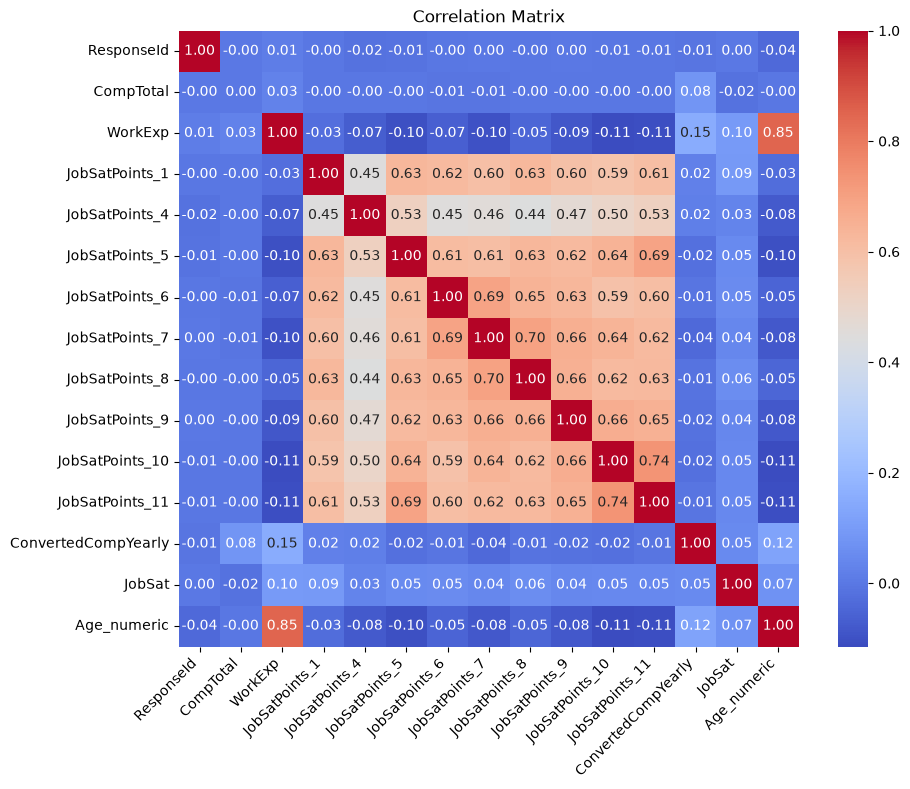

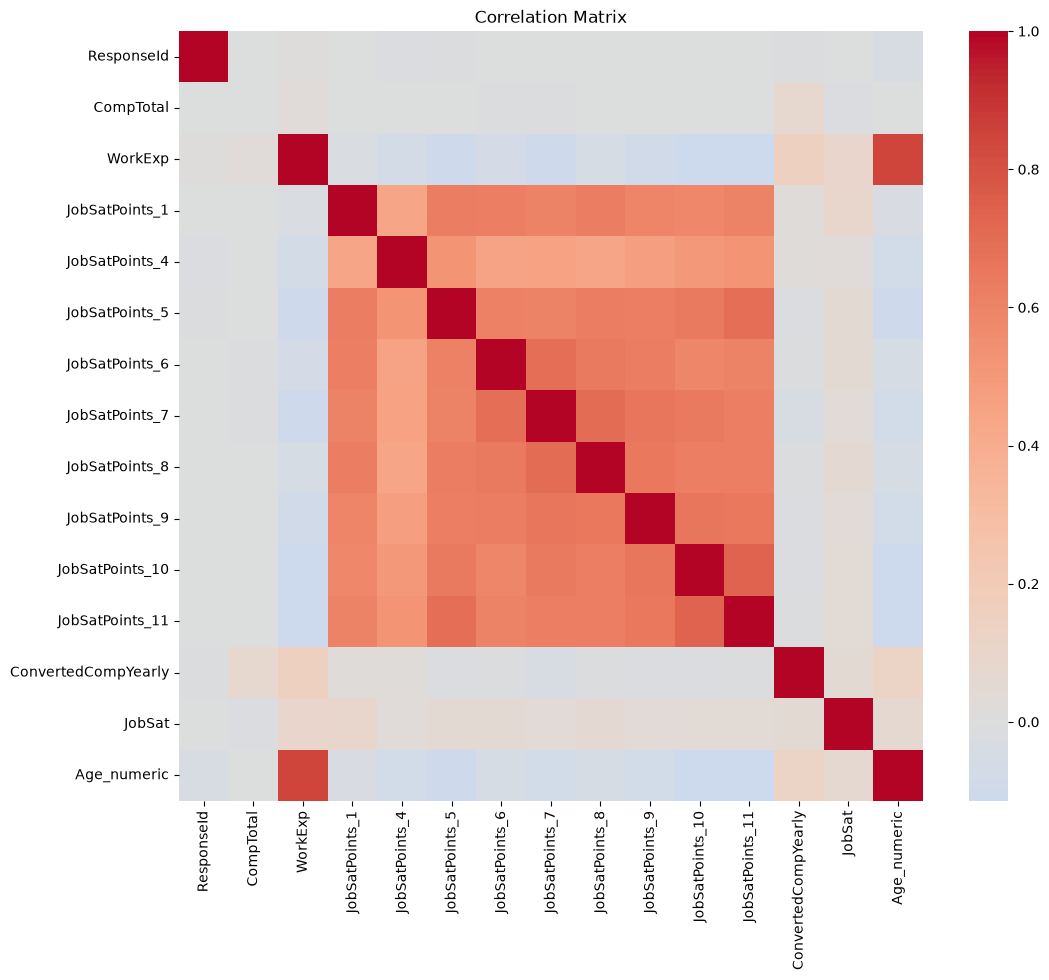

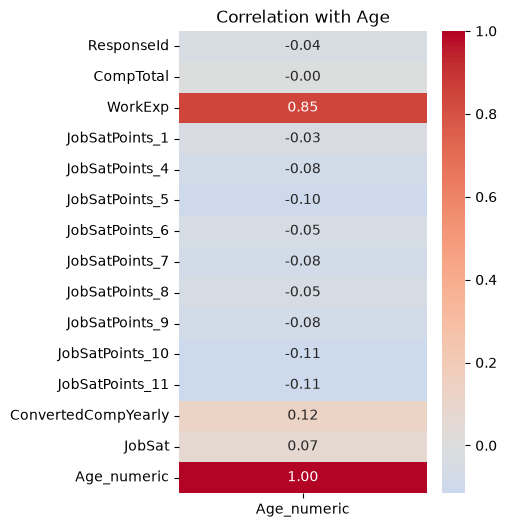

In [15]:

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize = (10,8) )
sns.heatmap(correlation_matrix, cmap ="coolwarm", annot =True, fmt =".2f")
plt.title("Correlation Matrix")
plt.xticks(rotation = 45,ha = "right")
plt.show()

plt.figure(figsize=(12, 10))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.show()

plt.figure(figsize=(4, 6))

sns.heatmap(
    correlation_matrix[["Age_numeric"]],
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Correlation with Age")
plt.show()

<h3> Summary </h3>


This exercise, developed essential skills in **Exploratory Data Analysis (EDA)** with a focus on outlier detection and removal. Specifically:


- Loaded and explored the dataset to understand its structure.

- Analyzed the distribution of respondents across industries.

- Identified and removed high compensation outliers using statistical thresholds and the Interquartile Range (IQR) method.

- Performed correlation analysis, including transforming the `Age` column into numeric values for better analysis.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-1|1.1|Madhusudan Moole|Reviewed and updated lab|                                                                                    
|2024-09-29|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
